# RQ1 SSL Validation (Standalone)
**Generated:** 2026-02-25 02:09

This notebook validates **Research Question 1 (RQ1)** using the **real-world SSL dataset**.

## What this notebook does
1. **Loads raw SSL CSV** from `data/raw/SSL_Returns_df_yoy.csv`  
2. **Builds an engineered SSL dataset** required for RQ1 (`Returns`, `total_loss`, date parsing) and saves it under:
   - `data/processed/rq1_ssl/rq1_ssl_engineered.parquet`
3. **Builds an RQ1 canonical dataset** (aligned to your RQ1 pipeline) and saves:
   - `rq1_ssl_base_canonical.parquet`
   - `rq1_ssl_by_category`, `rq1_ssl_by_brand`, `rq1_ssl_by_department`
4. Runs **RQ1 statistical tests** (same framework as your TheLook RQ1 pipeline)
5. Recreates **all 7 RQ1 visuals**, **SAVES** them and **DISPLAYS** them in the notebook.

> Note: The plotting functions in your project require `out_path` so figures are always saved for reproducibility.
> This notebook displays the saved images immediately after each plot.


## 1) Project setup
This cell finds the project root (folder containing `src/`) and adds it to `sys.path` so imports work reliably.

In [38]:

import sys
from pathlib import Path

project_root = Path.cwd().resolve()
while not (project_root / "src").exists() and project_root.parent != project_root:
    project_root = project_root.parent

if not (project_root / "src").exists():
    raise RuntimeError("Cannot find project root containing 'src/' directory.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:", project_root)


Project root: D:\Users\RSM\Downloads\Data Analytics\Capstone\v3\unfc-capstone-project


## 2) Imports and styling
Loads your RQ1 modules and sets the plot style.

If you edit any `src/*.py` files while the notebook is open, restart the kernel to avoid cached imports.

In [39]:

import pandas as pd
from pathlib import Path

from IPython.display import Image, display

def show_saved_fig(path: Path, width: int = 1200):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Figure not found: {path}")
    display(Image(filename=str(path), width=width))

# --- Project modules ---
from src.rq1_ssl_preprocessing import (
    build_and_save_rq1_ssl_engineered,
    RQ1SSLPreprocessConfig,
)

from src.rq1_ssl_validation import (
    build_and_save_rq1_ssl_dataset,
    RQ1SSLMapping,
)

import src.rq1_stats as rq1_stats
import src.rq1_visuals as rq1_visuals

from src.visualization import (
    set_plot_style,
    plot_top_groups_total_erosion,
    plot_severity_vs_volume_decomposition,
    plot_profit_erosion_distribution_log,
    plot_bootstrap_ci_mean_by_group,
)

set_plot_style()

RQ1_SSL_OUT_DIR = project_root / "data" / "processed" / "rq1_ssl"
RQ1_SSL_FIG_DIR = project_root / "figures" / "rq1_ssl"
RQ1_SSL_OUT_DIR.mkdir(parents=True, exist_ok=True)
RQ1_SSL_FIG_DIR.mkdir(parents=True, exist_ok=True)

print("RQ1_SSL_OUT_DIR:", RQ1_SSL_OUT_DIR)
print("RQ1_SSL_FIG_DIR:", RQ1_SSL_FIG_DIR)


RQ1_SSL_OUT_DIR: D:\Users\RSM\Downloads\Data Analytics\Capstone\v3\unfc-capstone-project\data\processed\rq1_ssl
RQ1_SSL_FIG_DIR: D:\Users\RSM\Downloads\Data Analytics\Capstone\v3\unfc-capstone-project\figures\rq1_ssl


## 3) Step 1 — Preprocess raw SSL (create engineered dataset)

### Input
- `data/raw/SSL_Returns_df_yoy.csv`

### Output
- `data/processed/rq1_ssl/rq1_ssl_engineered.parquet`
- (optional) `data/processed/rq1_ssl/rq1_ssl_engineered.csv`

### What gets engineered (minimum required for RQ1)
- `Returns` coerced to boolean (or inferred if missing)
- `total_loss` created/standardized as a **magnitude** proxy of erosion
- date columns parsed when present


In [40]:

cfg = RQ1SSLPreprocessConfig(
    raw_path=Path("data/raw/SSL_Returns_df_yoy.csv"),
    out_dir=Path("data/processed/rq1_ssl"),
    out_stem="rq1_ssl_engineered",
)

ssl_engineered_df, meta, engineered_path = build_and_save_rq1_ssl_engineered(
    project_root=project_root,
    cfg=cfg,
    save_csv=True,
)

print("Engineered SSL saved to:", engineered_path)
print("Rows:", len(ssl_engineered_df), "| Cols:", ssl_engineered_df.shape[1])

print("\nDerivation metadata:")
for k, v in meta.items():
    print(f"- {k}: {v}")

ssl_engineered_df.head(3)


Engineered SSL saved to: D:\Users\RSM\Downloads\Data Analytics\Capstone\v3\unfc-capstone-project\data\processed\rq1_ssl\rq1_ssl_engineered.parquet
Rows: 133800 | Cols: 82

Derivation metadata:
- parsed_date:Booked Date: to_datetime(errors='coerce')
- parsed_date:Billed Date: to_datetime(errors='coerce')
- parsed_date:Reference Booked Date: to_datetime(errors='coerce')
- parsed_date:Prev_Return_Date: to_datetime(errors='coerce')
- Returns: coerced from Returns
- total_loss: abs(total_loss)
- dropped_rows_missing_total_loss: 0
- saved_parquet: D:\Users\RSM\Downloads\Data Analytics\Capstone\v3\unfc-capstone-project\data\processed\rq1_ssl\rq1_ssl_engineered.parquet
- saved_csv: D:\Users\RSM\Downloads\Data Analytics\Capstone\v3\unfc-capstone-project\data\processed\rq1_ssl\rq1_ssl_engineered.csv


,Profile Class,Business Unit,Grand Parent Name,Bill To Act #,Bill To Account Name,Bill To State,Ship To Act #,Ship To Account Name,Ship To State,Territory Region,...,Is End of Quarter,Is Peak Season,Is Fiscal Year End,Lines Per Order,Billed Lines Per Order,Days B4 Return,Prev_Return_Date,Time_Since_Last_Return,Repeat_Customer_6M,Time_Since_Last_Return_bin
0,ETAILER,81,LA WAFFLE,1959740,AMAZON DROPSHIP VENDOR,WA,1959740,--------------------,TX,CHANNEL SALES,...,False,0,0,1,1,7.0,NaT,NaN,0,NaN
1,ETAILER,81,LA WAFFLE,1959740,AMAZON DROPSHIP VENDOR,WA,1959740,--------------------,TX,CHANNEL SALES,...,False,0,0,1,1,13.0,2025-02-07,11.0,1,<30d
2,PUBLIC DISTRICTS,81,LINCOLN PUBLIC SCHOOLS,422142,LINCOLN PUBLIC SCHOOLS,NE,168282,007 LINCOLN PS DISTRICT WAREHOUSE,NE,MOUNTAIN-PACIFIC NORTHWEST,...,False,0,0,1,1,15.0,2023-12-19,59.0,1,30-90d


## 4) Step 2 — Build canonical RQ1 SSL dataset + artifacts

This step maps SSL columns into the same **canonical RQ1 fields** used by your main RQ1 pipeline:
- `is_returned_item`
- `profit_erosion`
- `category`, `brand`, `department`

It also produces group-level artifacts:
- by category
- by brand
- by department


In [41]:

mapping = RQ1SSLMapping(
    ssl_returns_col="Returns",
    ssl_loss_col="total_loss",
    ssl_category_col="Class",
    ssl_brand_col="Supplier Name",
    ssl_department_col="Department",
)

base_df, artifacts, paths = build_and_save_rq1_ssl_dataset(
    ssl_engineered_df=ssl_engineered_df,
    out_dir=RQ1_SSL_OUT_DIR,
    mapping=mapping,
    prefix="rq1_ssl",
)

returned_df = base_df[base_df["is_returned_item"] == 1].copy()

erosion_cat = artifacts["by_category"]
erosion_brand = artifacts["by_brand"]
erosion_dept = artifacts["by_department"]

print("Saved outputs:")
for k, p in paths.items():
    print("-", k, "=>", p)

print("\nReturned items rows:", len(returned_df))
returned_df.head(3)


Saved outputs:
- base => D:\Users\RSM\Downloads\Data Analytics\Capstone\v3\unfc-capstone-project\data\processed\rq1_ssl\rq1_ssl_base_canonical.parquet
- returned => D:\Users\RSM\Downloads\Data Analytics\Capstone\v3\unfc-capstone-project\data\processed\rq1_ssl\rq1_ssl_returned_items.parquet
- by_category_parquet => D:\Users\RSM\Downloads\Data Analytics\Capstone\v3\unfc-capstone-project\data\processed\rq1_ssl\rq1_ssl_by_category.parquet
- by_category_csv => D:\Users\RSM\Downloads\Data Analytics\Capstone\v3\unfc-capstone-project\data\processed\rq1_ssl\rq1_ssl_by_category.csv
- by_brand_parquet => D:\Users\RSM\Downloads\Data Analytics\Capstone\v3\unfc-capstone-project\data\processed\rq1_ssl\rq1_ssl_by_brand.parquet
- by_brand_csv => D:\Users\RSM\Downloads\Data Analytics\Capstone\v3\unfc-capstone-project\data\processed\rq1_ssl\rq1_ssl_by_brand.csv
- by_department_parquet => D:\Users\RSM\Downloads\Data Analytics\Capstone\v3\unfc-capstone-project\data\processed\rq1_ssl\rq1_ssl_by_department.p

,Profile Class,Business Unit,Grand Parent Name,Bill To Act #,Bill To Account Name,Bill To State,Ship To Act #,Ship To Account Name,Ship To State,Territory Region,...,Days B4 Return,Prev_Return_Date,Time_Since_Last_Return,Repeat_Customer_6M,Time_Since_Last_Return_bin,is_returned_item,profit_erosion,category,brand,department
0,ETAILER,81,LA WAFFLE,1959740,AMAZON DROPSHIP VENDOR,WA,1959740,--------------------,TX,CHANNEL SALES,...,7.0,NaT,NaN,0,NaN,1,40.146,PAINT,HANDY ART INC,ART SUPPLIES
1,ETAILER,81,LA WAFFLE,1959740,AMAZON DROPSHIP VENDOR,WA,1959740,--------------------,TX,CHANNEL SALES,...,13.0,2025-02-07,11.0,1,<30d,1,44.006,DRAWING,HANDY ART INC,ART SUPPLIES
2,PUBLIC DISTRICTS,81,LINCOLN PUBLIC SCHOOLS,422142,LINCOLN PUBLIC SCHOOLS,NE,168282,007 LINCOLN PS DISTRICT WAREHOUSE,NE,MOUNTAIN-PACIFIC NORTHWEST,...,15.0,2023-12-19,59.0,1,30-90d,1,125.130,SOFT PLAY,EDUSHAPE,EARLY LEARNING ENVIRONMENTS


## 5) Step 3 — Statistical tests (same framework as TheLook RQ1)

We run the same inferential testing approach used in your RQ1 pipeline:
- Category-level test: do mean erosion values differ by category?
- Brand-level test: do mean erosion values differ by brand?

> Tip: We print p-values using scientific notation to keep them readable.


In [42]:

summary_cat, posthoc_cat = rq1_stats.run_factor(
    returned_df,
    group_col="category",
    value_col="profit_erosion",
    min_group_size=5,
    run_posthoc=True,
    max_groups_posthoc=12,
    max_rows_per_group_posthoc=2000,
)

summary_brand, posthoc_brand = rq1_stats.run_factor(
    returned_df,
    group_col="brand",
    value_col="profit_erosion",
    min_group_size=5,
    run_posthoc=True,
    max_groups_posthoc=12,
    max_rows_per_group_posthoc=2000,
)

# Save summaries
pd.DataFrame([summary_cat]).to_csv(RQ1_SSL_OUT_DIR / "rq1_ssl_test_summary_category.csv", index=False)
pd.DataFrame([summary_brand]).to_csv(RQ1_SSL_OUT_DIR / "rq1_ssl_test_summary_brand.csv", index=False)

if isinstance(posthoc_cat, pd.DataFrame) and not posthoc_cat.empty:
    posthoc_cat.to_csv(RQ1_SSL_OUT_DIR / "rq1_ssl_posthoc_category.csv", index=False)
if isinstance(posthoc_brand, pd.DataFrame) and not posthoc_brand.empty:
    posthoc_brand.to_csv(RQ1_SSL_OUT_DIR / "rq1_ssl_posthoc_brand.csv", index=False)

print(f"Category test p-value: {summary_cat['p_value']:.4e} | reject_h0={summary_cat['reject_h0']}")
print(f"Brand test p-value:    {summary_brand['p_value']:.4e} | reject_h0={summary_brand['reject_h0']}")

summary_cat, summary_brand


Category test p-value: 0.0000e+00 | reject_h0=True
Brand test p-value:    0.0000e+00 | reject_h0=True


({'factor': 'category',
  'test_used': 'kruskal',
  'p_value': 0.0,
  'effect_size': 0.2738624287172857,
  'effect_metric': 'epsilon_squared',
  'reject_h0': True,
  'meets_effect_threshold': True,
  'success_criteria_met': True,
  'n_groups': 297,
  'n_rows': 133708,
  'posthoc_ran': True,
  'posthoc_note': 'Dunn post-hoc ran on top 12 groups with up to 2000 rows per group.'},
 {'factor': 'brand',
  'test_used': 'kruskal',
  'p_value': 0.0,
  'effect_size': 0.2168156301176444,
  'effect_metric': 'epsilon_squared',
  'reject_h0': True,
  'meets_effect_threshold': True,
  'success_criteria_met': True,
  'n_groups': 584,
  'n_rows': 133262,
  'posthoc_ran': True,
  'posthoc_note': 'Dunn post-hoc ran on top 12 groups with up to 2000 rows per group.'})

## 6) Step 4 — Visual replication (ALL 7 RQ1 visuals)

We recreate and **display** the full RQ1 visual suite (same flow as the RQ1 pipeline):

1. Top Categories by Total Profit Erosion  
2. Top Brands by Total Profit Erosion  
3. Return Rate vs Mean Profit Erosion per Return (Category)  
4. Top Departments by Total Profit Erosion  
5. Severity vs Volume decomposition (Category)  
6. Distribution of Profit Erosion (log scale)  
7. Bootstrap 95% CI for Category mean erosion  


### 6.1 Top Categories by Total Profit Erosion

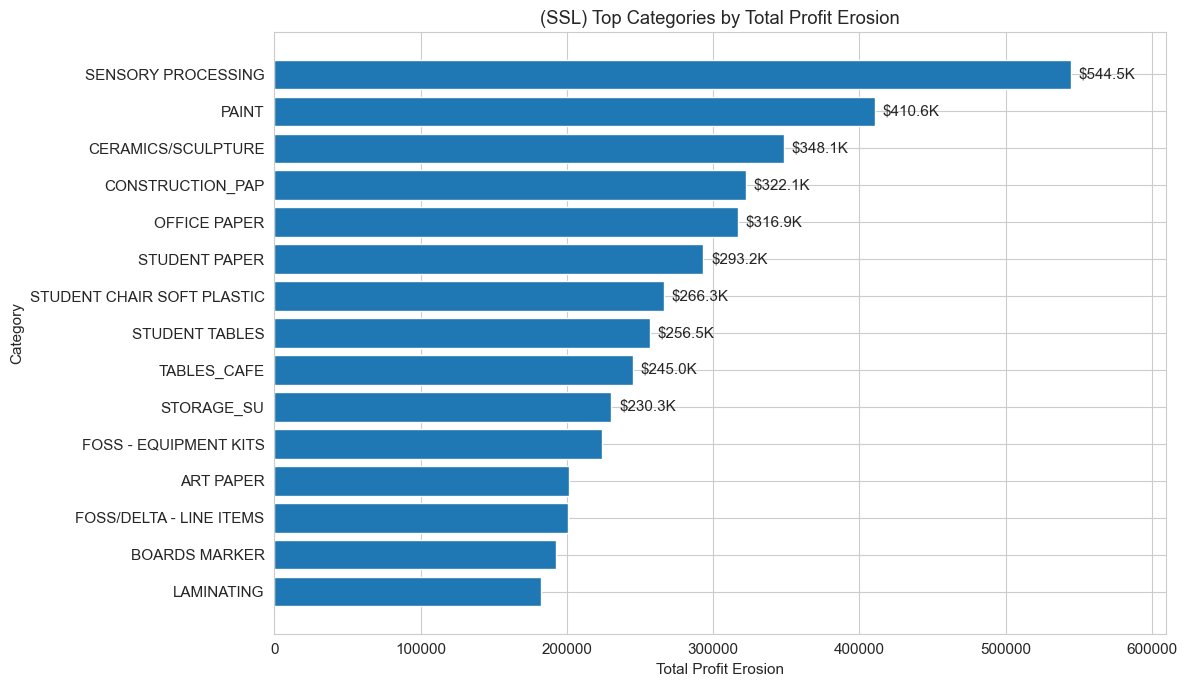

In [43]:

fig_path = RQ1_SSL_FIG_DIR / "fig1_top_categories_total_erosion.png"

plot_top_groups_total_erosion(
    erosion_cat,
    group_col="category",
    value_col="total_profit_erosion",
    top_n=15,
    out_path=fig_path,
    title="(SSL) Top Categories by Total Profit Erosion",
)

show_saved_fig(fig_path)


### 6.2 Top Brands by Total Profit Erosion

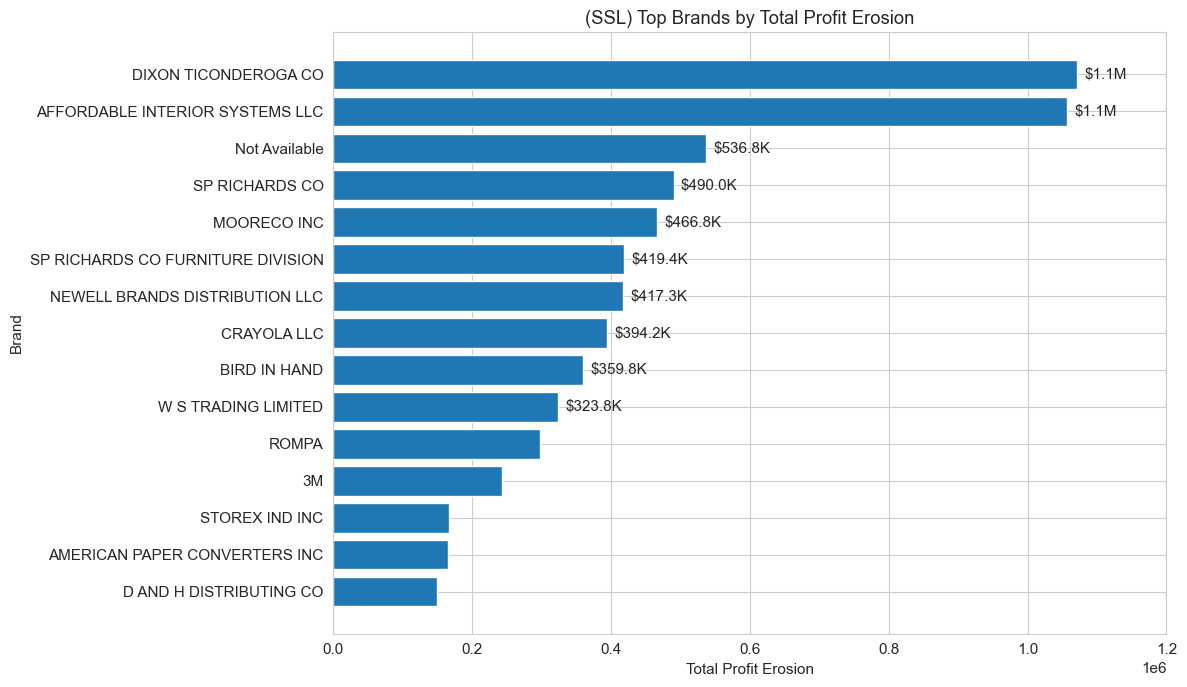

In [44]:

fig_path = RQ1_SSL_FIG_DIR / "fig2_top_brands_total_erosion.png"

plot_top_groups_total_erosion(
    erosion_brand,
    group_col="brand",
    value_col="total_profit_erosion",
    top_n=15,
    out_path=fig_path,
    title="(SSL) Top Brands by Total Profit Erosion",
)

show_saved_fig(fig_path)


### 6.3 Return Rate vs Mean Profit Erosion per Return (Category)
This mirrors the RQ1 "rate vs severity" relationship and uses bubble size to reflect returned item volume.

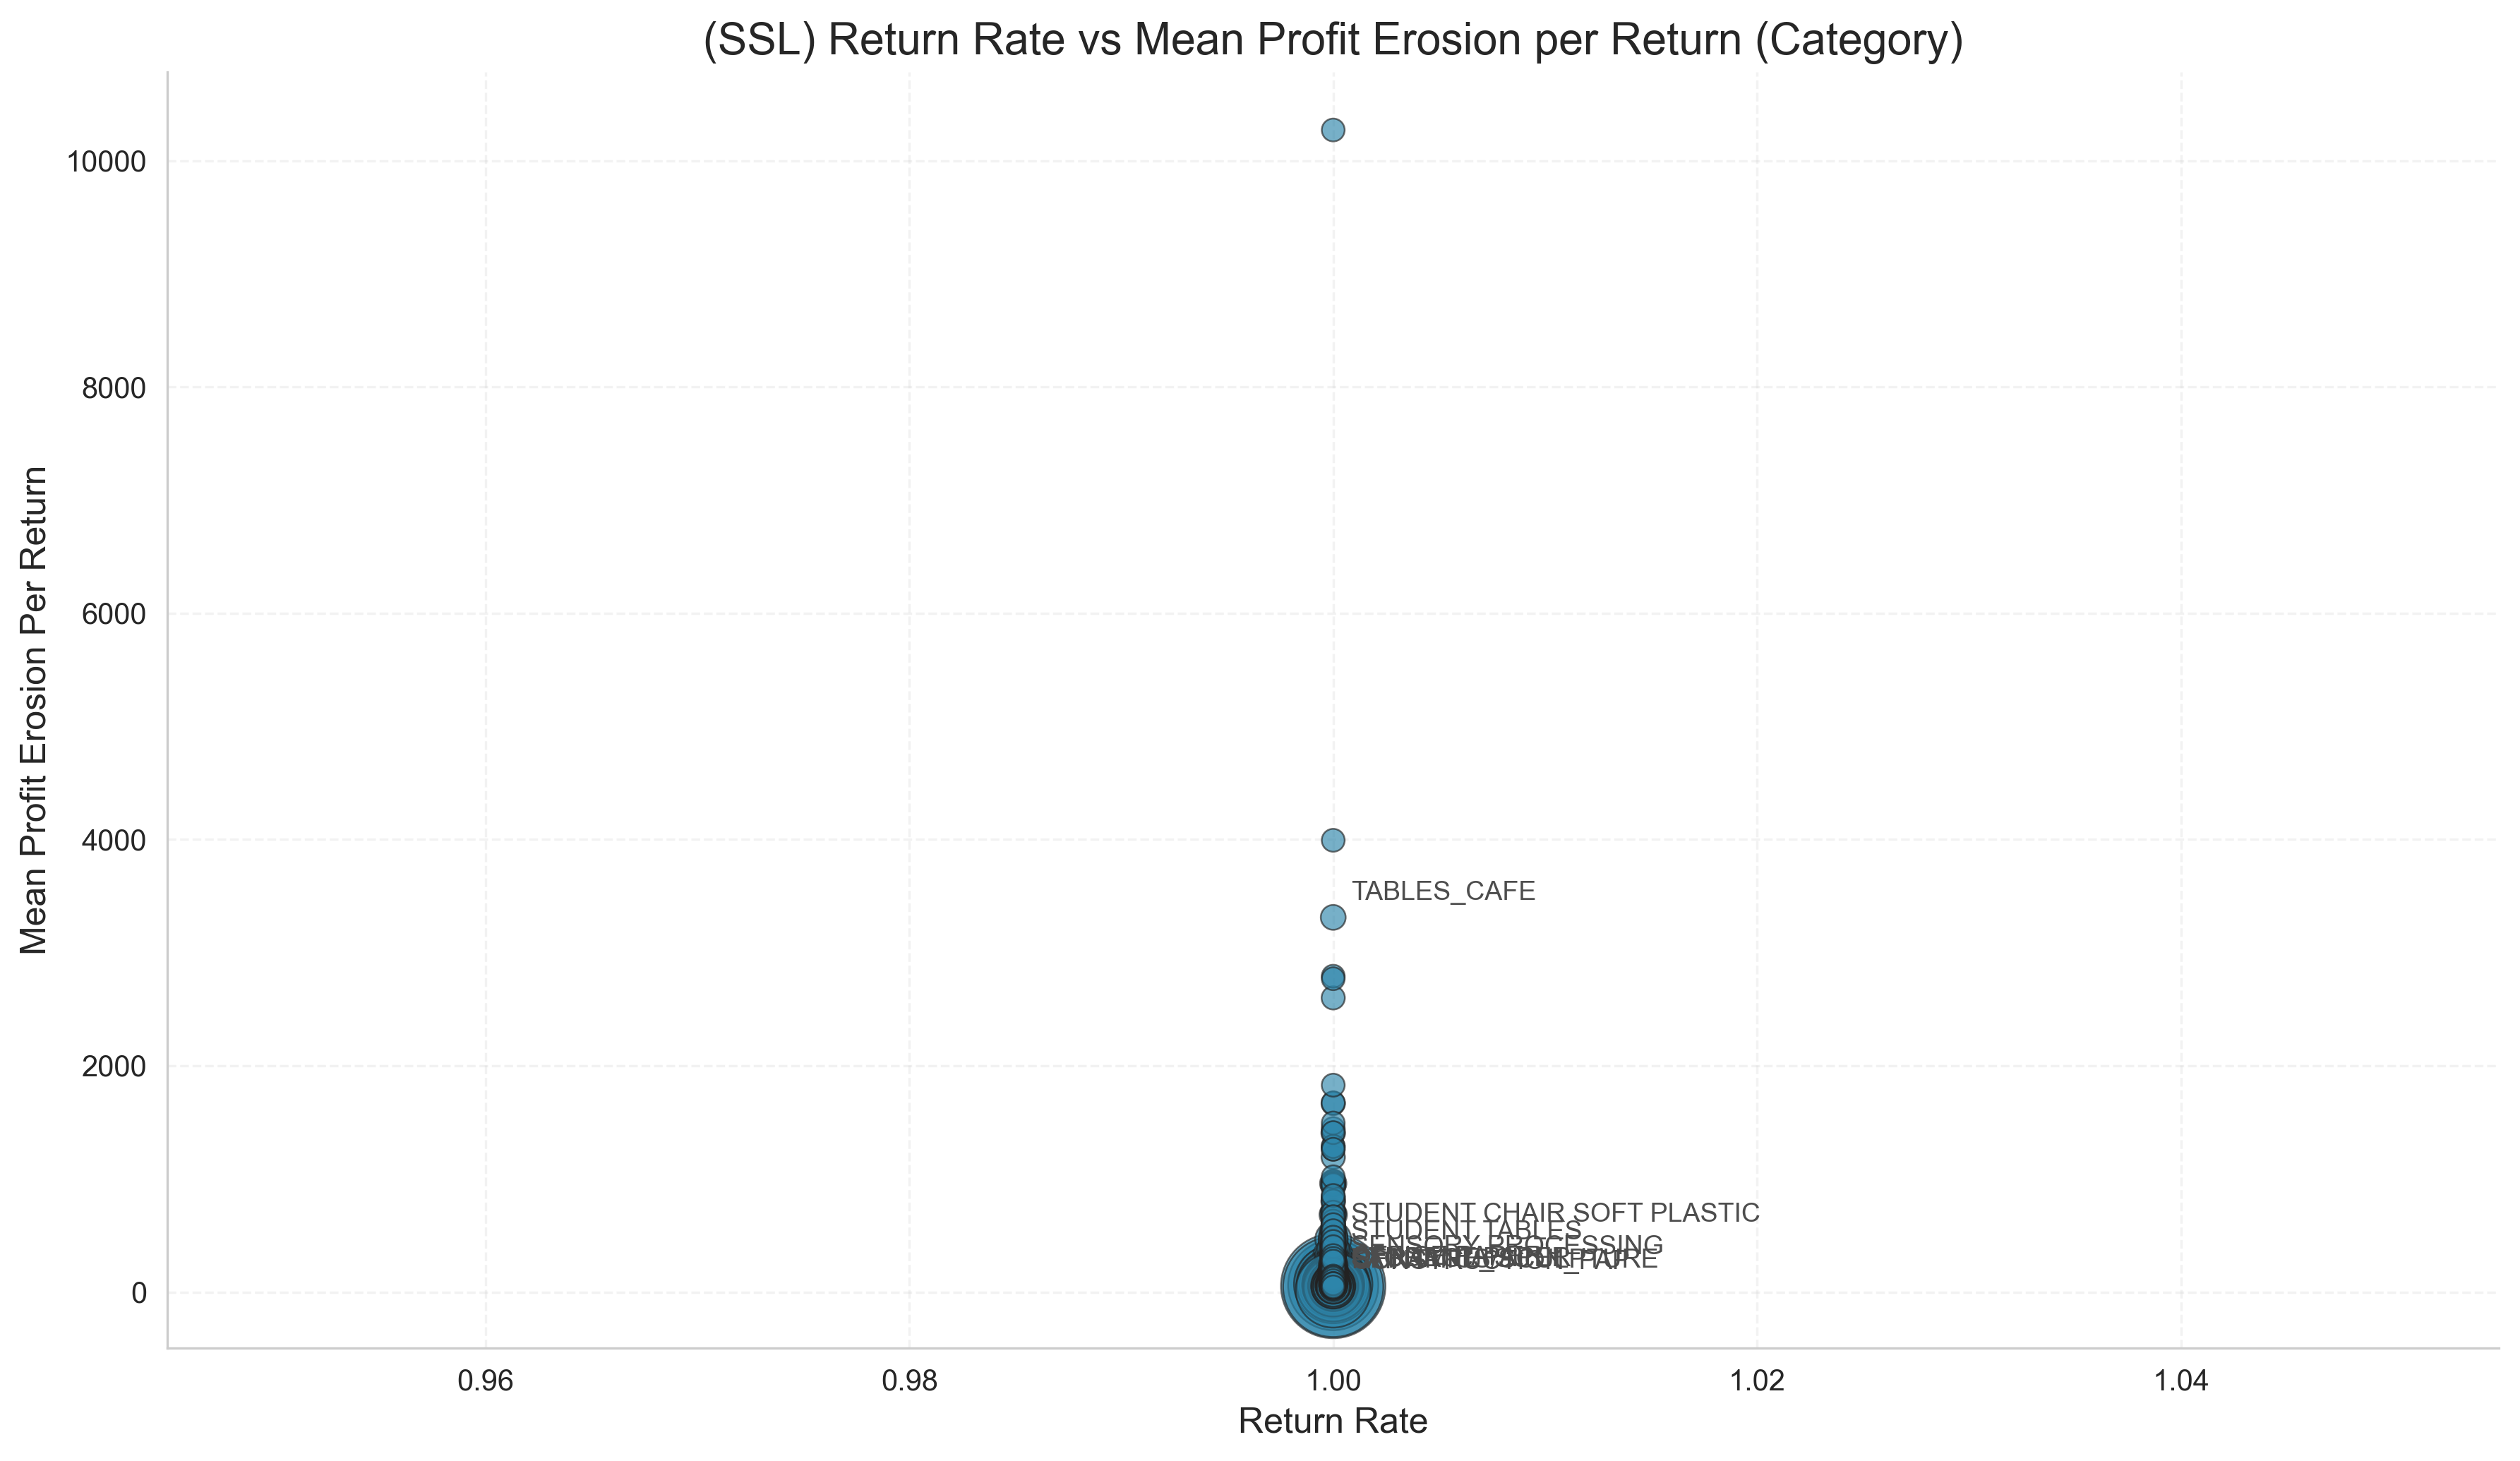

In [45]:

fig_path = RQ1_SSL_FIG_DIR / "fig3_return_rate_vs_mean_erosion_category.png"

y_col = "mean_profit_erosion_per_return" if "mean_profit_erosion_per_return" in erosion_cat.columns else "avg_profit_erosion"

rq1_visuals.plot_return_rate_vs_mean_erosion(
    erosion_cat,
    x_col="return_rate",
    y_col=y_col,
    label_col="category",
    size_col="returned_items",
    out_path=fig_path,
    title="(SSL) Return Rate vs Mean Profit Erosion per Return (Category)",
    annotate_top_k=10,
)

show_saved_fig(fig_path)


### 6.4 Top Departments by Total Profit Erosion

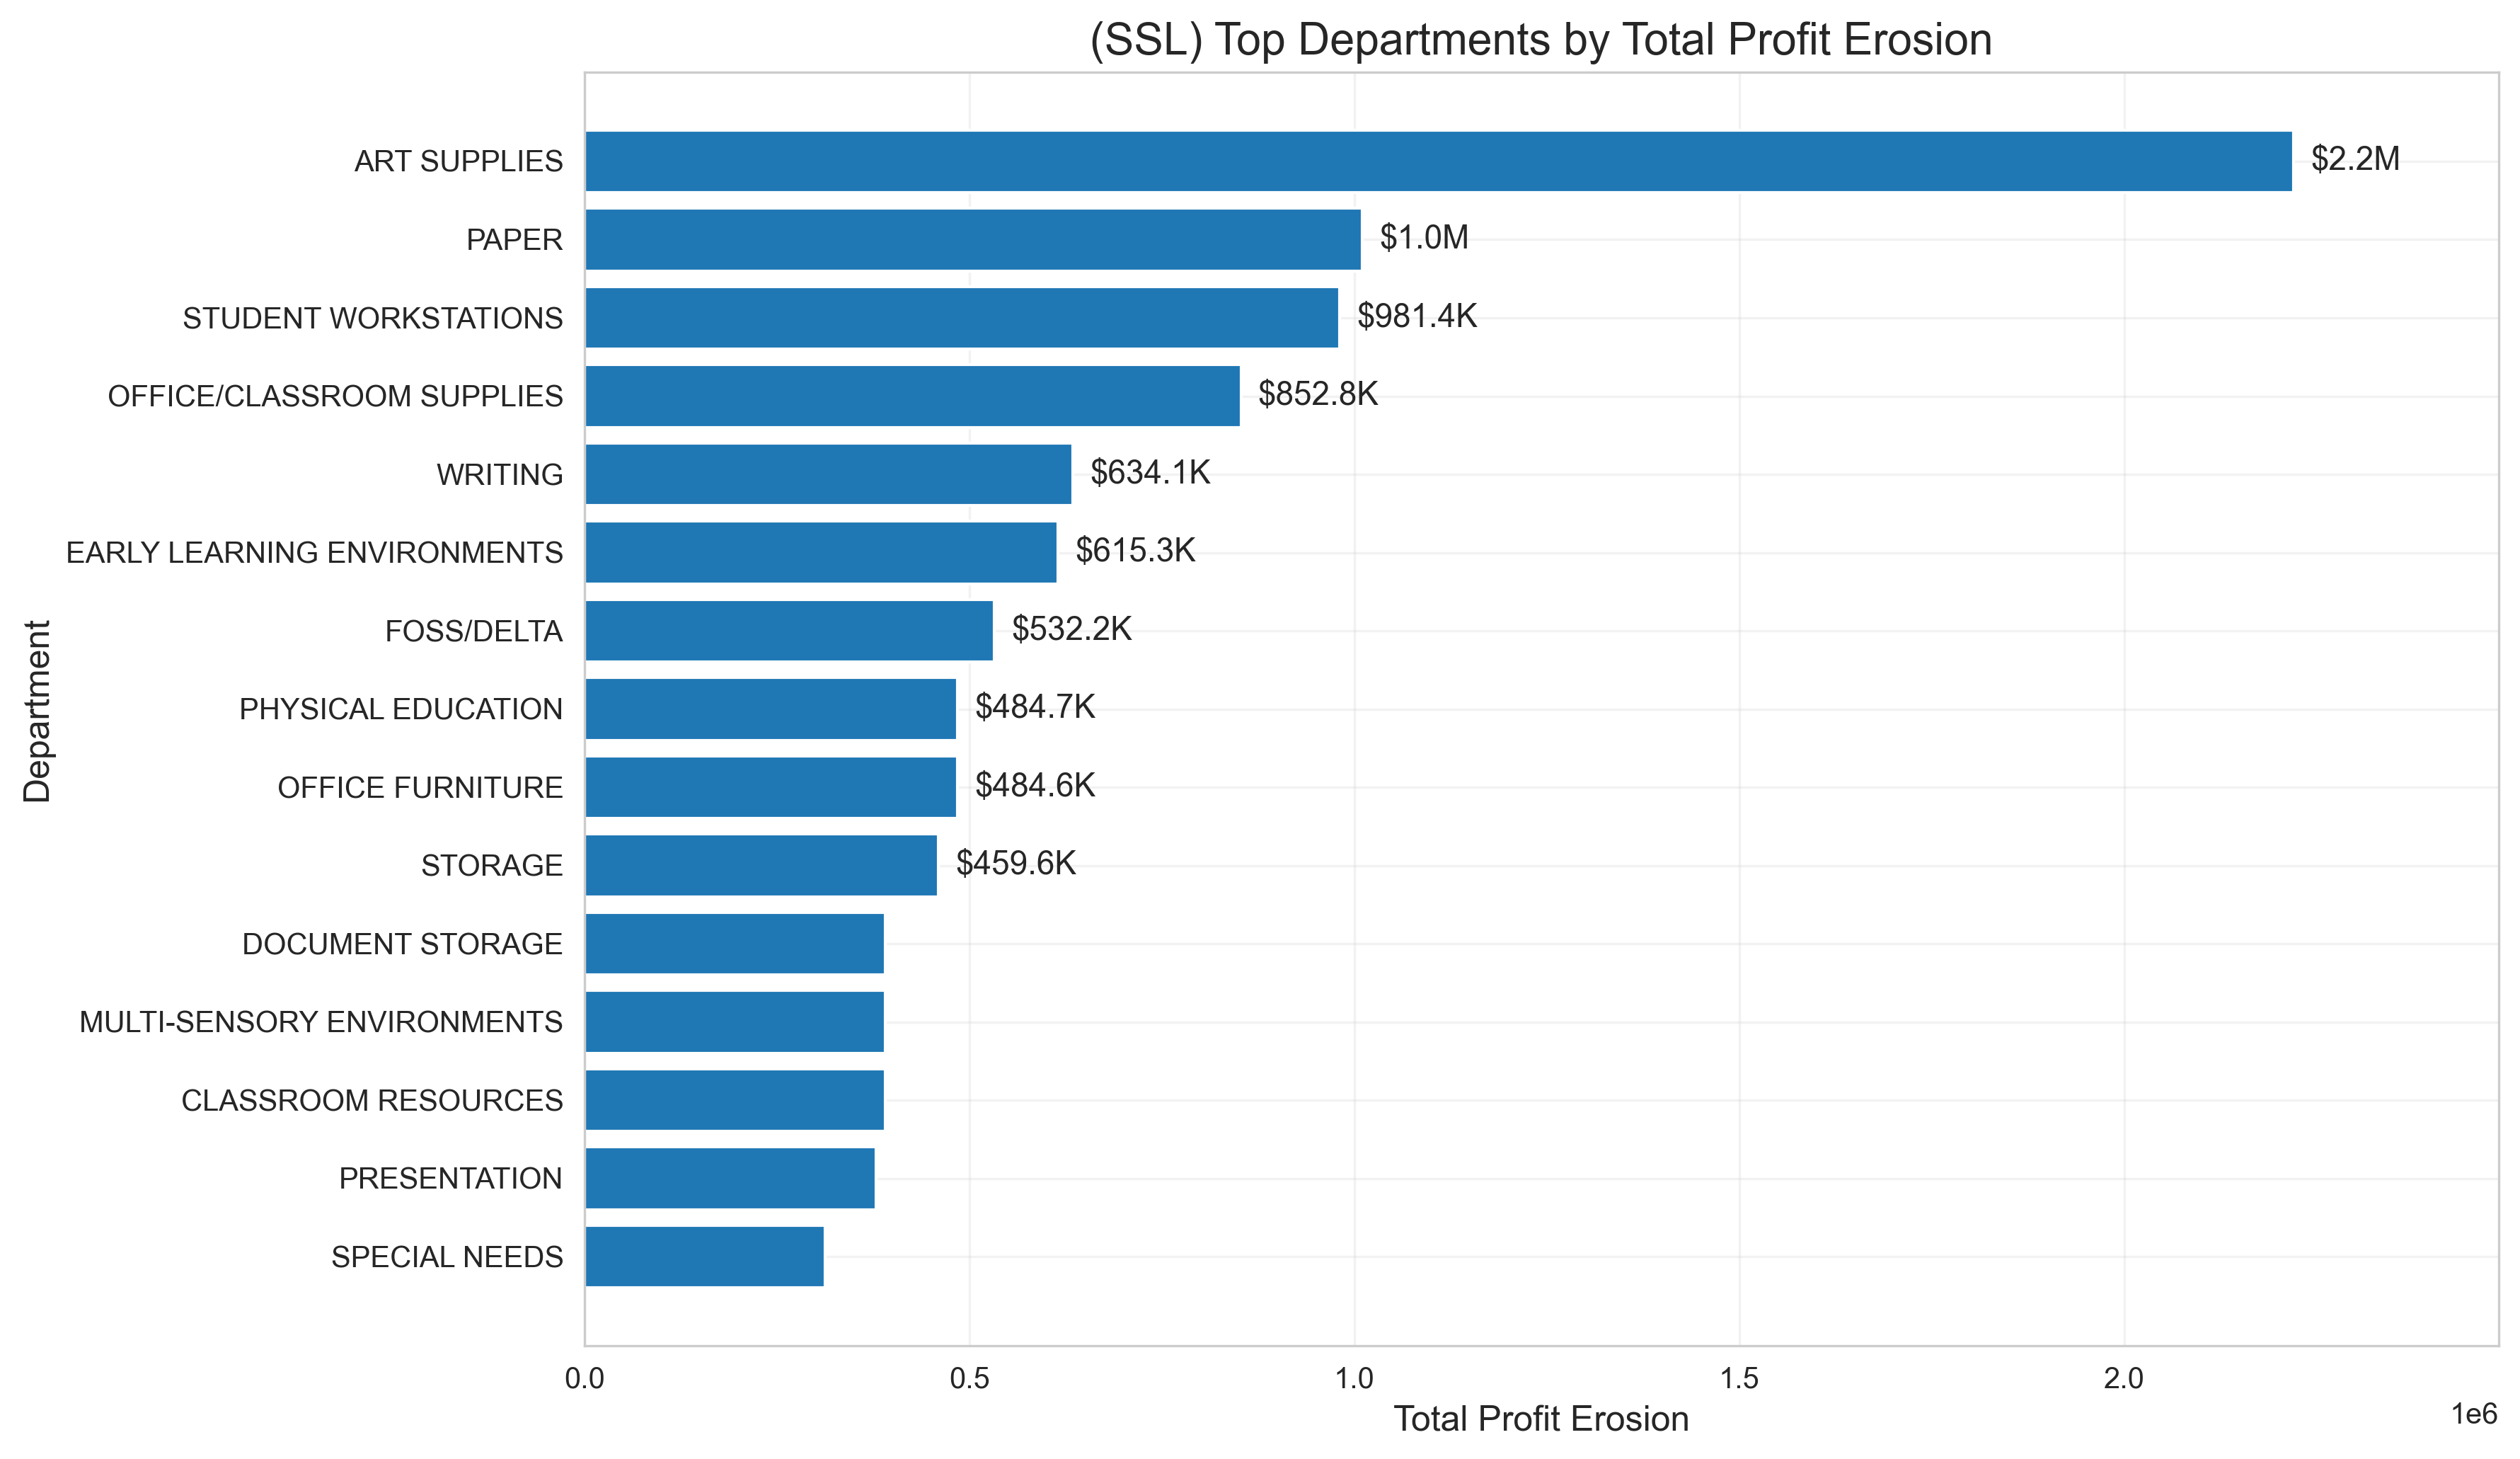

In [46]:

fig_path = RQ1_SSL_FIG_DIR / "fig4_top_departments_total_erosion.png"

plot_top_groups_total_erosion(
    erosion_dept,
    group_col="department",
    value_col="total_profit_erosion",
    top_n=15,
    out_path=fig_path,
    title="(SSL) Top Departments by Total Profit Erosion",
)

show_saved_fig(fig_path)


### 6.5 Severity vs Volume Decomposition (Category)
This shows the decomposition: **total erosion = returned_items × avg erosion per return**.

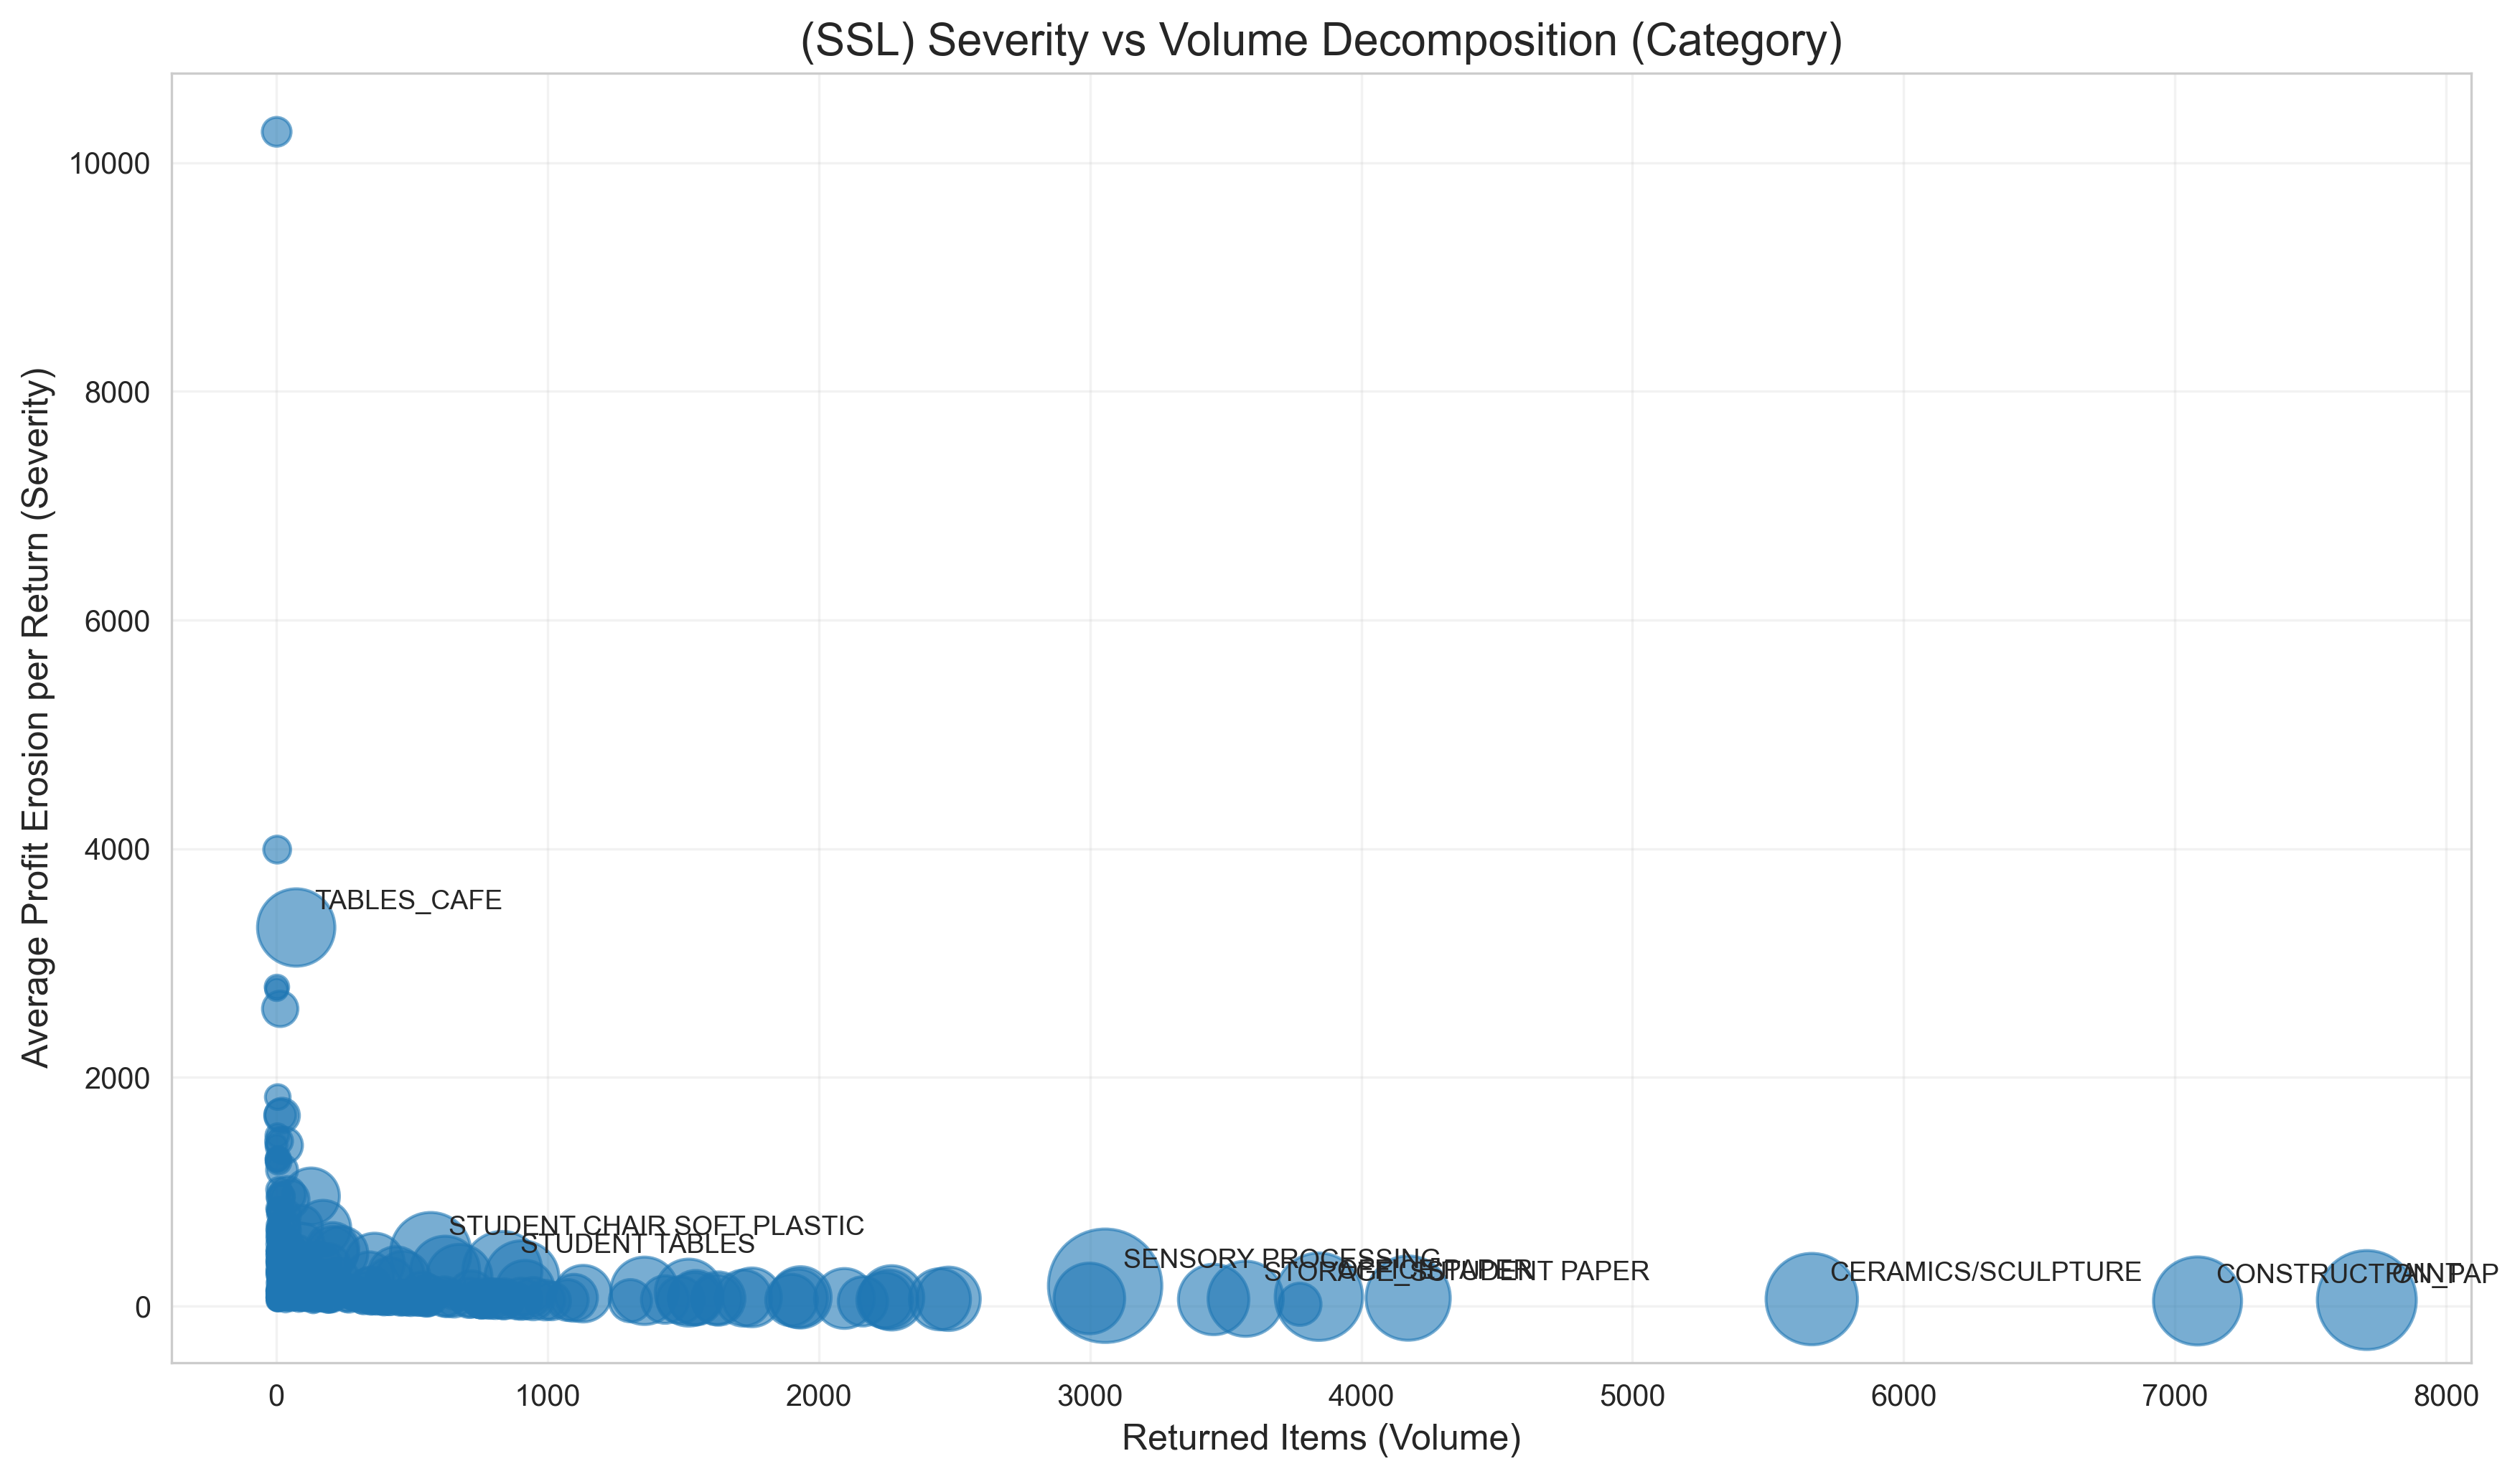

In [47]:

fig_path = RQ1_SSL_FIG_DIR / "fig5_severity_vs_volume_category.png"

avg_col = "mean_profit_erosion_per_return" if "mean_profit_erosion_per_return" in erosion_cat.columns else "avg_profit_erosion"

plot_severity_vs_volume_decomposition(
    erosion_cat,
    group_col="category",
    returned_items_col="returned_items",
    avg_erosion_col=avg_col,
    total_erosion_col="total_profit_erosion",
    out_path=fig_path,
    title="(SSL) Severity vs Volume Decomposition (Category)",
    annotate_top_k=10,
)

show_saved_fig(fig_path)


### 6.6 Distribution of Profit Erosion (Log Scale)
This highlights the heavy-tail nature of erosion (few very costly returns).

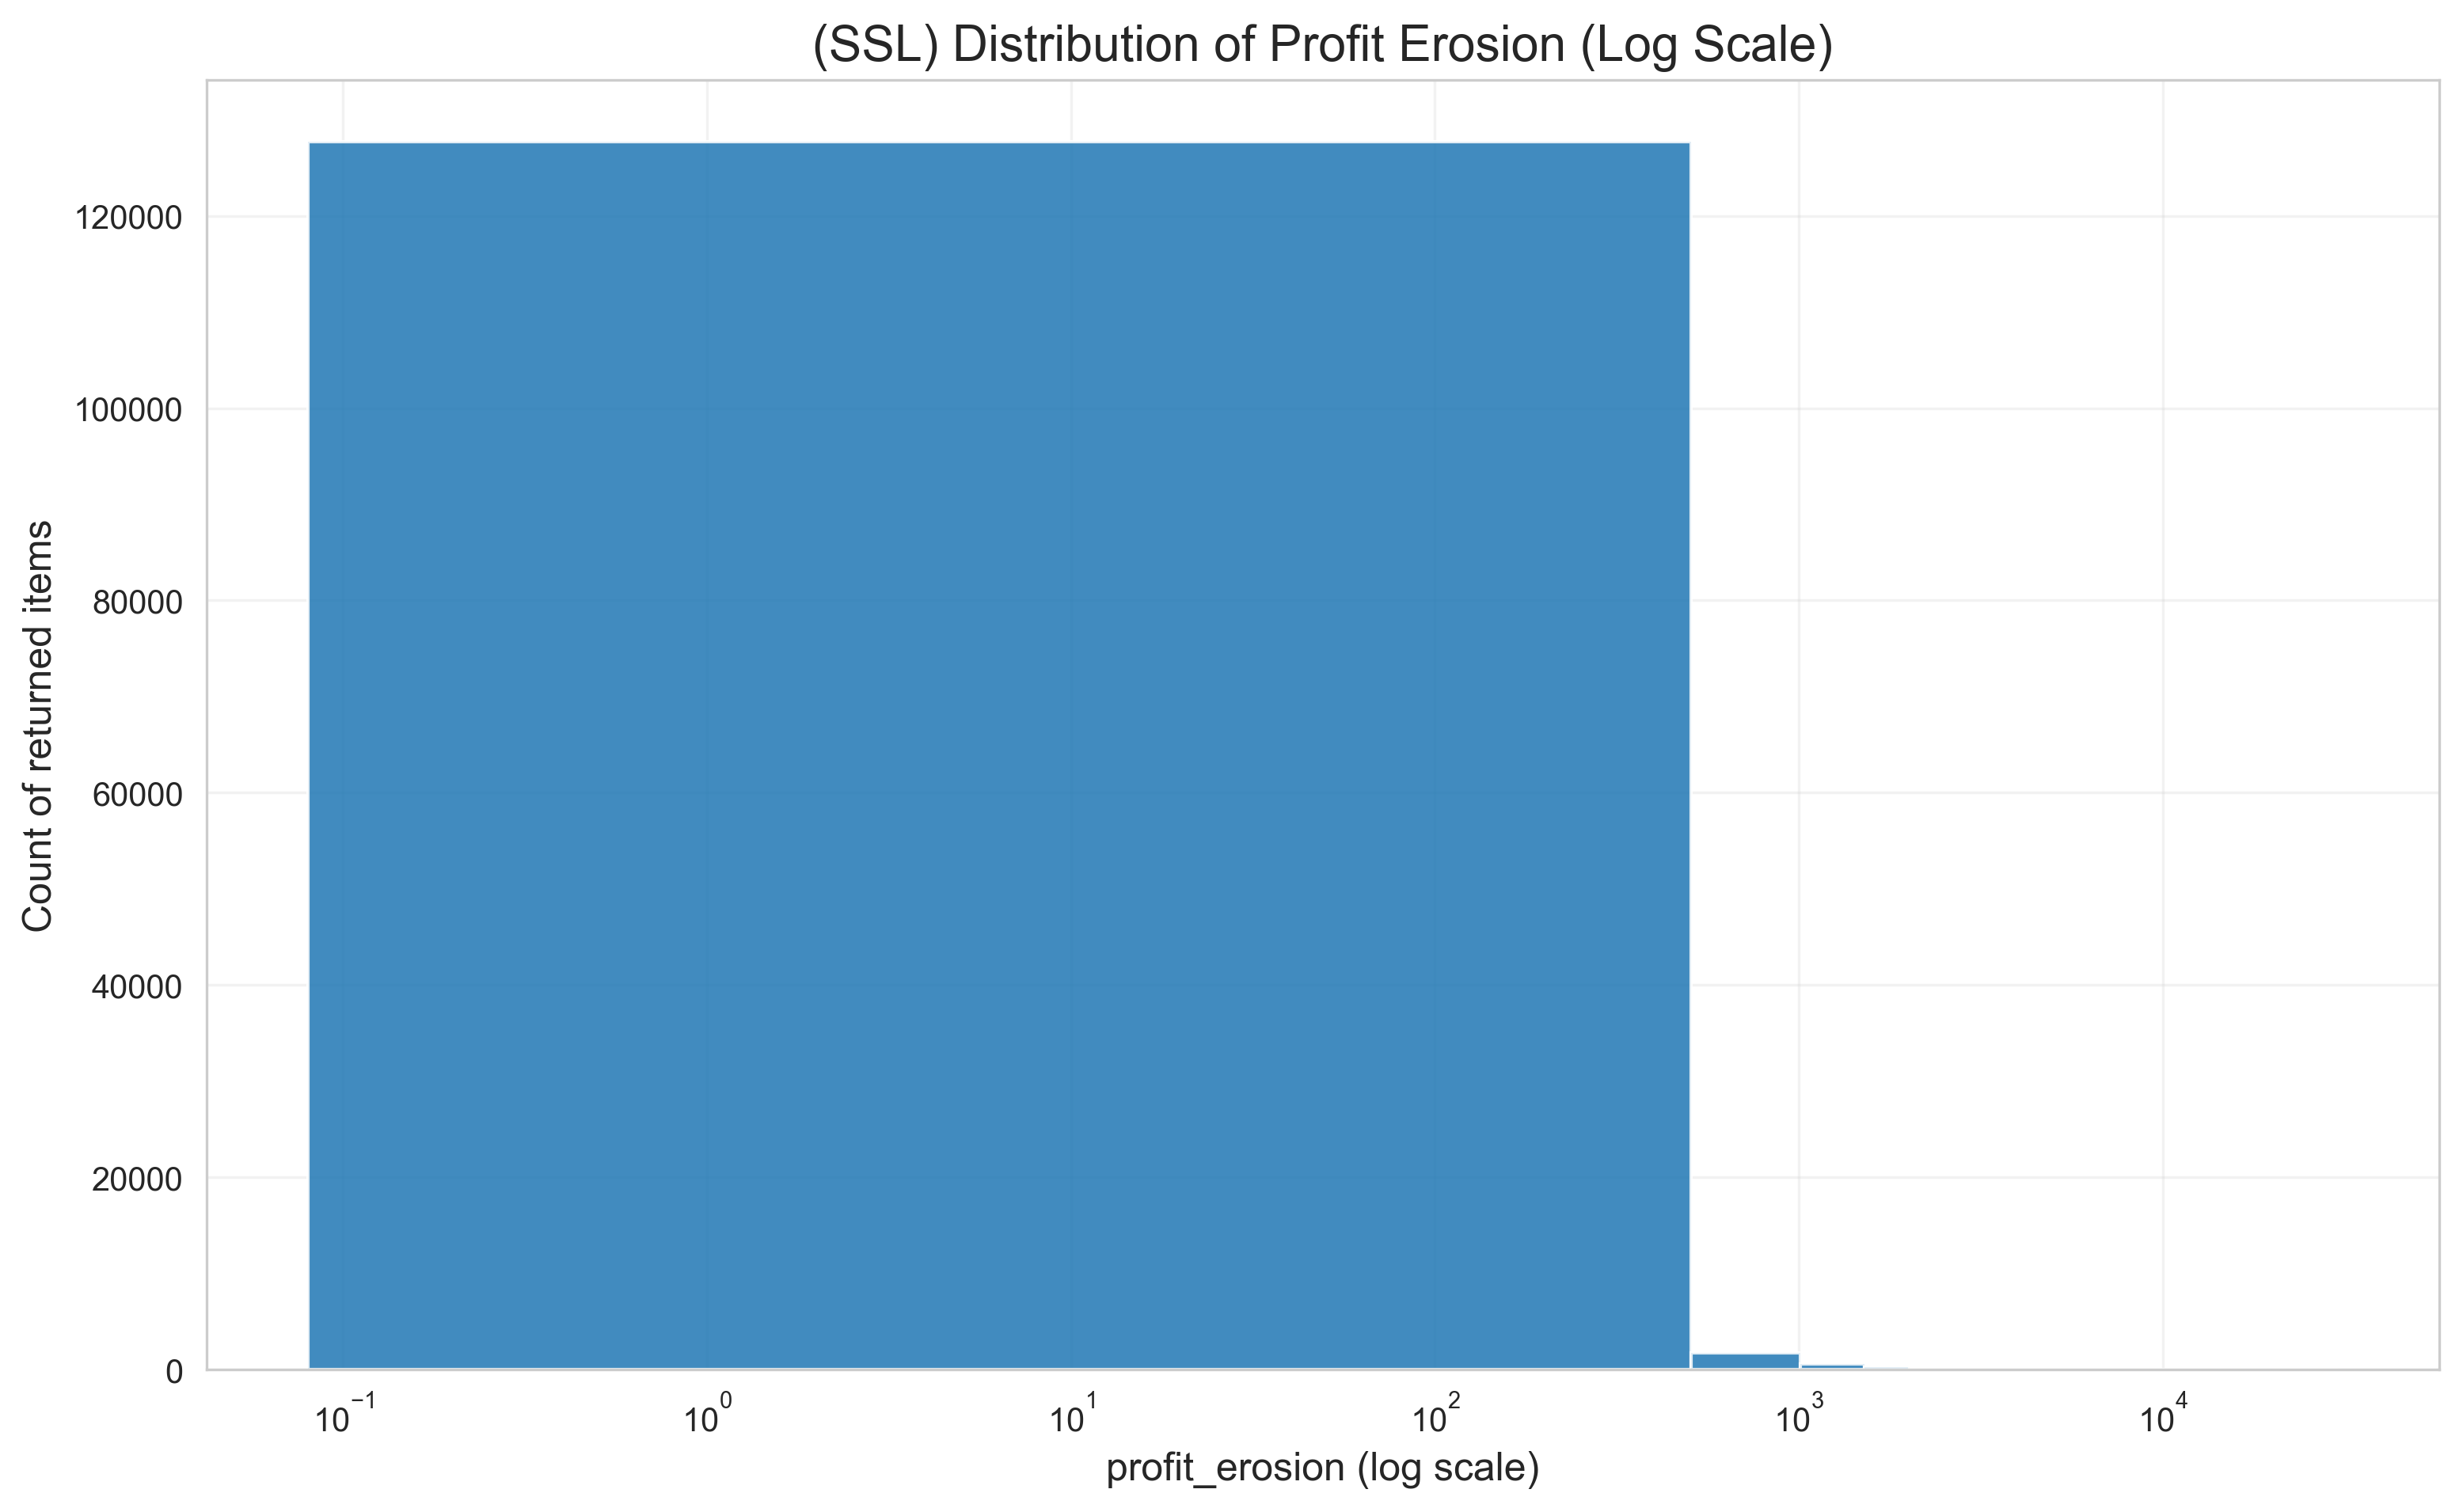

In [48]:

fig_path = RQ1_SSL_FIG_DIR / "fig6_profit_erosion_distribution_log.png"

plot_profit_erosion_distribution_log(
    returned_df,
    value_col="profit_erosion",
    out_path=fig_path,
    title="(SSL) Distribution of Profit Erosion (Log Scale)",
    bins=60,
)

show_saved_fig(fig_path)


### 6.7 Bootstrap 95% CI for Mean Profit Erosion (Category)
We bootstrap group means to show estimate stability and uncertainty. The CI table is also saved under `data/processed/rq1_ssl/`.

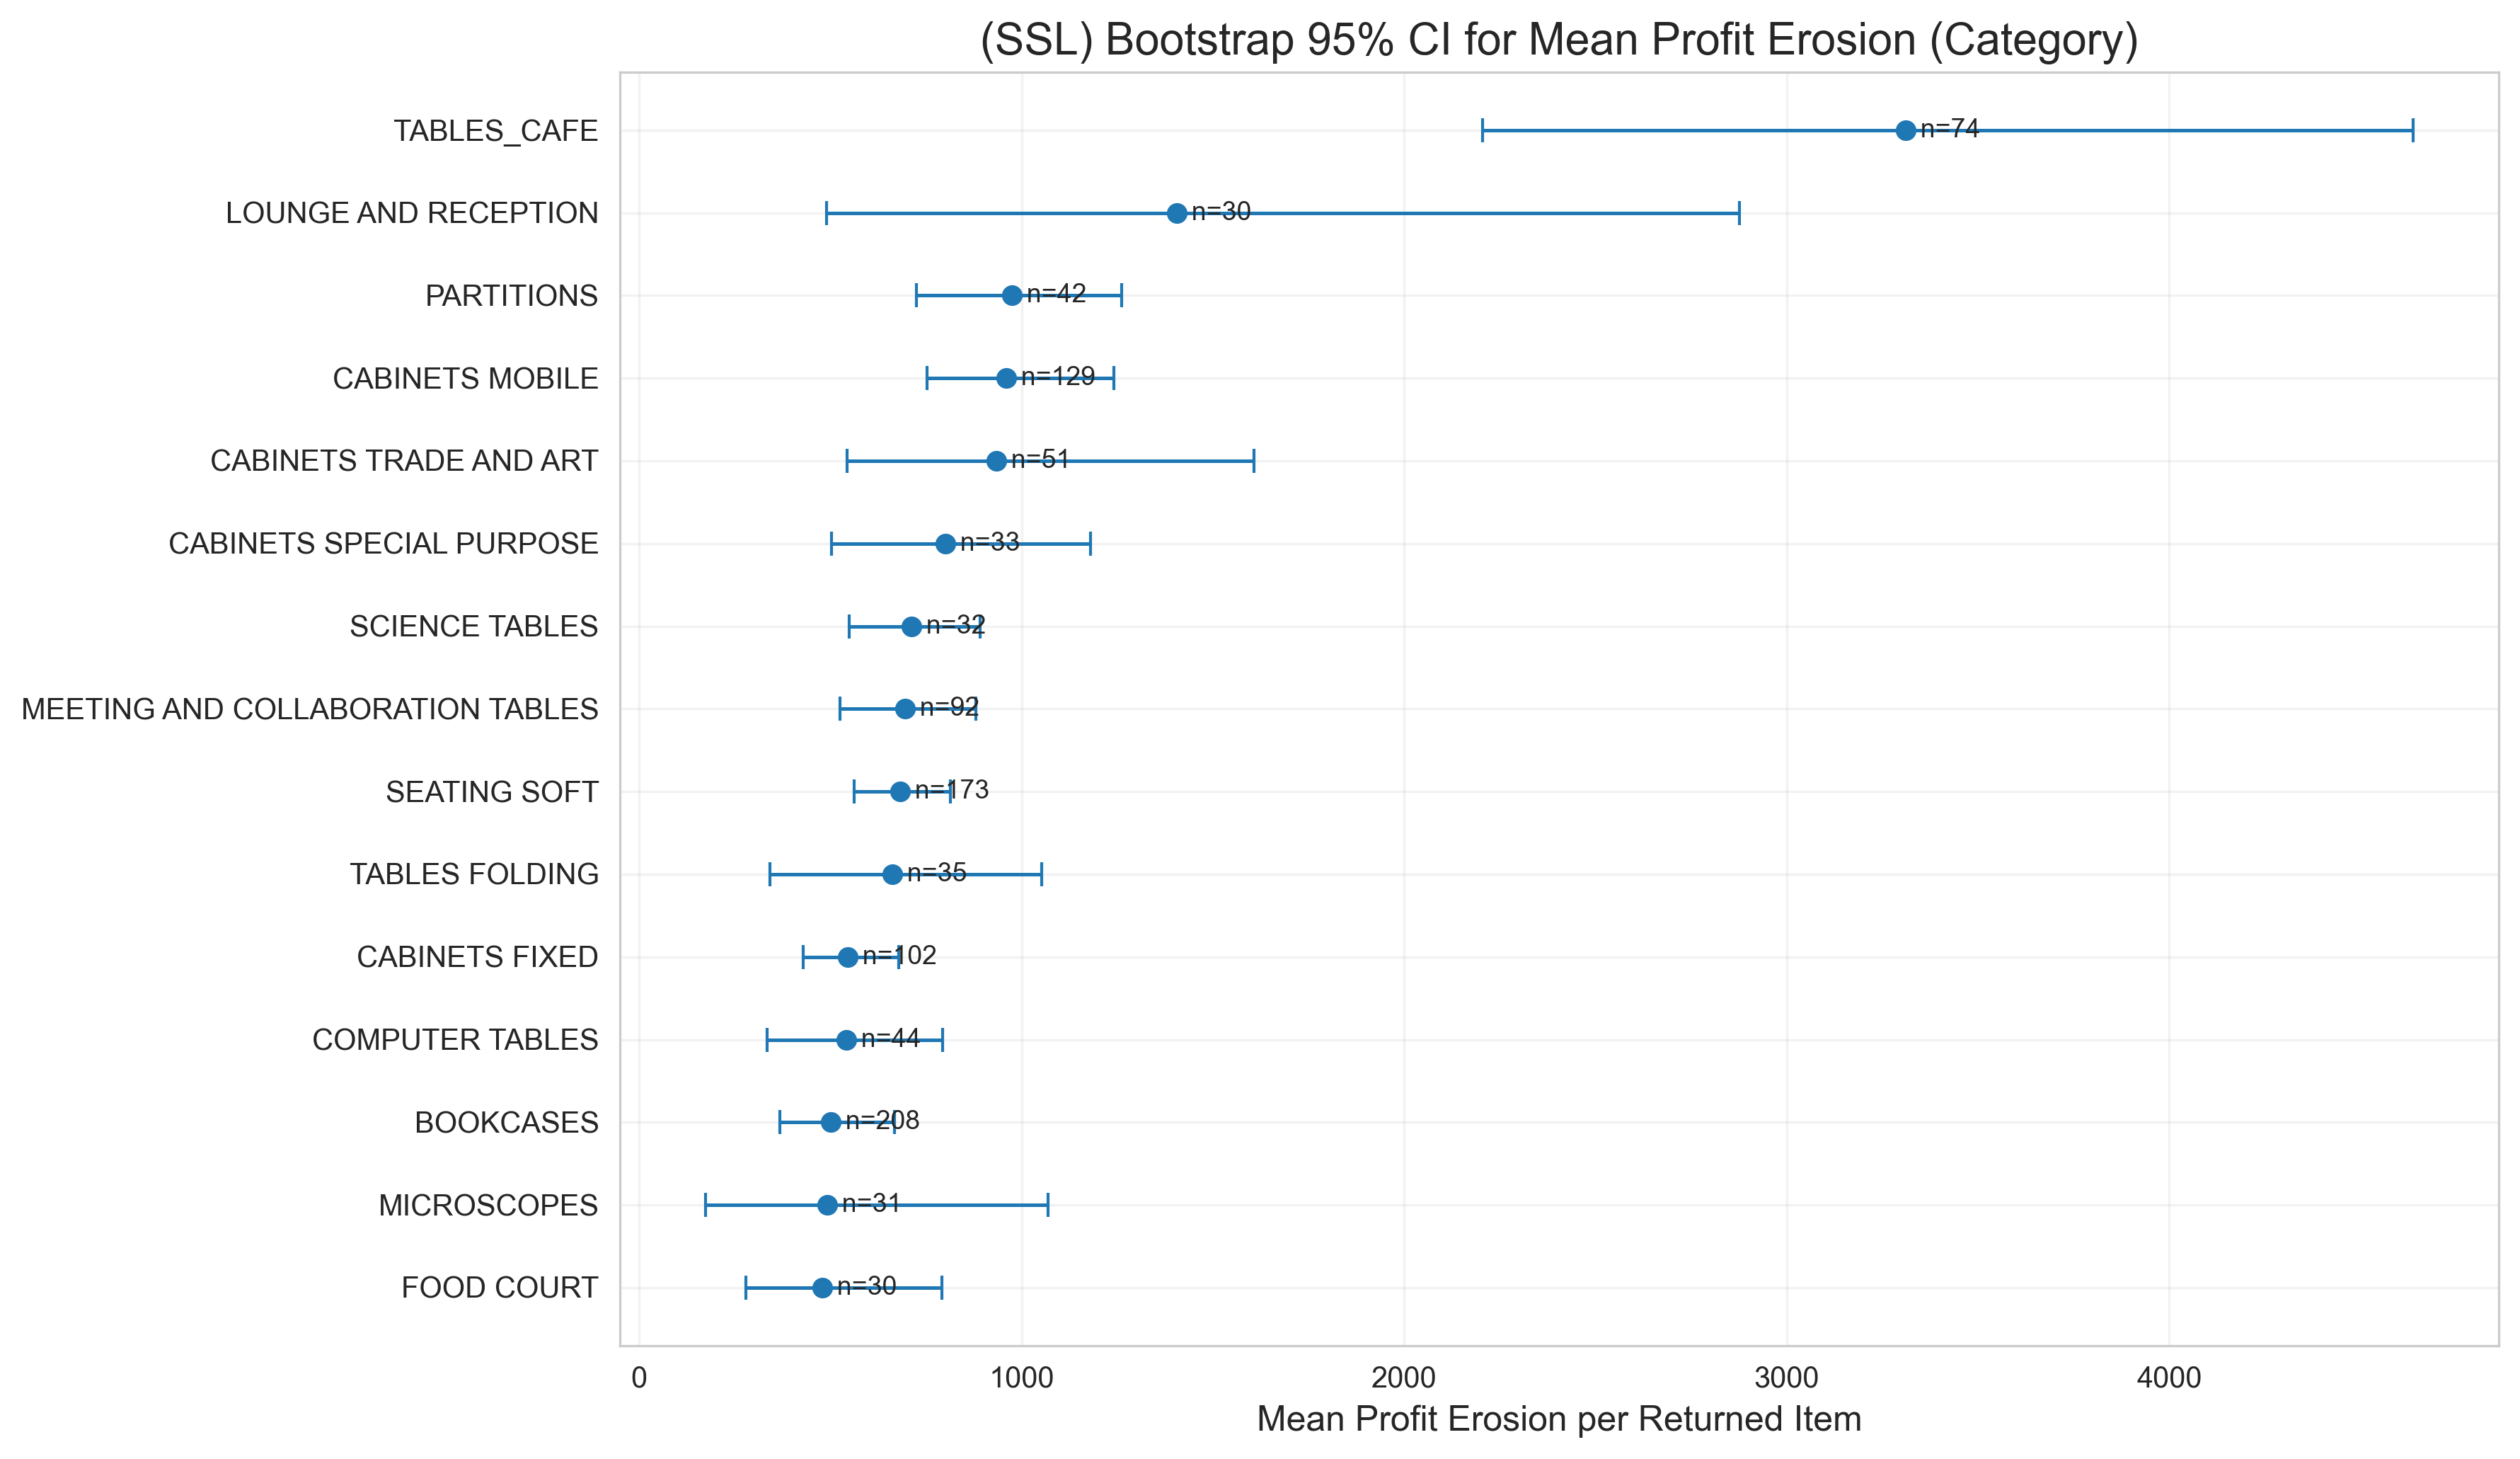

,category,n_returned_items,mean_profit_erosion,ci_low_95,ci_high_95,ci_width
0,TABLES_CAFE,74,3311.343243,2204.237274,4638.236389,2433.999115
1,LOUNGE AND RECEPTION,30,1405.928667,490.187767,2875.667067,2385.479300
2,PARTITIONS,42,975.367333,725.481567,1260.816904,535.335336
3,CABINETS MOBILE,129,960.431178,752.113173,1240.407006,488.293833
4,CABINETS TRADE AND ART,51,934.897255,544.135613,1606.760730,1062.625117
5,CABINETS SPECIAL PURPOSE,33,800.501273,503.459992,1180.439444,676.979452
6,SCIENCE TABLES,32,712.760000,549.567312,892.405844,342.838531
7,MEETING AND COLLABORATION TABLES,92,694.850109,526.007845,880.877432,354.869587
8,SEATING SOFT,173,683.186035,561.506939,814.804609,253.297670
9,TABLES FOLDING,35,661.622971,341.707721,1053.123581,711.415860


In [49]:

fig_path = RQ1_SSL_FIG_DIR / "fig7_bootstrap_ci_category_mean.png"

ci_df, _ = plot_bootstrap_ci_mean_by_group(
    returned_df,
    group_col="category",
    value_col="profit_erosion",
    out_path=fig_path,
    title="(SSL) Bootstrap 95% CI for Mean Profit Erosion (Category)",
    n_boot=800,
    min_group_size=30,
    top_n_plot=15,
    random_state=42,
)

ci_df.to_csv(RQ1_SSL_OUT_DIR / "rq1_ssl_bootstrap_ci_category_mean.csv", index=False)
ci_df.to_parquet(RQ1_SSL_OUT_DIR / "rq1_ssl_bootstrap_ci_category_mean.parquet", index=False)

show_saved_fig(fig_path)
ci_df.head(10)


## 7) Outputs produced

### Data outputs (under `data/processed/rq1_ssl/`)
- `rq1_ssl_engineered.parquet`
- `rq1_ssl_base_canonical.parquet`
- `rq1_ssl_by_category.*`
- `rq1_ssl_by_brand.*`
- `rq1_ssl_by_department.*`
- statistical summaries + posthoc tables (CSV)
- bootstrap CI table (CSV + Parquet)

### Figures (under `figures/rq1_ssl/`)
- `fig1_top_categories_total_erosion.png`
- `fig2_top_brands_total_erosion.png`
- `fig3_return_rate_vs_mean_erosion_category.png`
- `fig4_top_departments_total_erosion.png`
- `fig5_severity_vs_volume_category.png`
- `fig6_profit_erosion_distribution_log.png`
- `fig7_bootstrap_ci_category_mean.png`
